TRASH RECOGNITION

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/metal/metal375.jpg
/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/metal/metal341.jpg
/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/metal/metal374.jpg
/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/metal/metal383.jpg
/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/metal/metal215.jpg
/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/metal/metal113.jpg
/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/metal/metal213.jpg
/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/metal/metal226.jpg
/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/metal/metal147.jpg
/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/metal/metal90.jpg
/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/metal/metal130.jpg
/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/metal/metal63.jpg
/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/metal/m

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [3]:
data_dir = '/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized'

# Tambahkan RandomGrayscale untuk menghilangkan informasi warna sesekali
# Tingkatkan intensitas ColorJitter agar model tidak terikat pada satu nuansa warna
transform = transforms.Compose([
    # --- PIL Image Transforms (Safe for PIL images) ---
    transforms.Resize((224, 224)),
    transforms.RandomRotation(45),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.2),
    transforms.RandomGrayscale(p=0.3),
    
    # --- Convert to Tensor (CRITICAL STEP) ---
    transforms.ToTensor(), 
    
    # --- Tensor Transforms (Only safe AFTER ToTensor) ---
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3)),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) 
])

full_dataset = datasets.ImageFolder(data_dir, transform=transform)

In [4]:
# Split dataset menjadi Data Latih (80%) dan Data Validasi (20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

In [5]:
# Buat DataLoader (untuk mengelompokkan data dalam batch)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Dataset berhasil dimuat! Jumlah kelas: {len(full_dataset.classes)}")
print(f"Kelas yang ditemukan: {full_dataset.classes}")

Dataset berhasil dimuat! Jumlah kelas: 6
Kelas yang ditemukan: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [6]:
from torchvision import models
import torch.nn as nn
import torch.optim as optim

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_weights = torch.tensor([1.5, 1.0, 1.2, 1.5, 1.0, 1.0]).to(device)

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

model = model.to(device)

for param in model.parameters():
    param.requires_grad = True


num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 6).to(device)

# Cek device dari layer fc
print(f"Layer FC ada di: {next(model.fc.parameters()).device}")

# Cek device dari layer pertama (conv1)
print(f"Layer Conv1 ada di: {next(model.conv1.parameters()).device}")

Layer FC ada di: cuda:0
Layer Conv1 ada di: cuda:0


In [8]:
# Tentukan Loss Function & Optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
# Hanya optimalkan parameter di layer terakhir yang baru kita buat
optimizer = optim.Adam(model.parameters(), lr=0.00001)

print("Model siap! ResNet50 telah dimodifikasi.")

Model siap! ResNet50 telah dimodifikasi.


In [9]:
import time

In [10]:
# --- Konfigurasi Early Stopping ---
patience = 3  # Berapa kali toleransi model boleh "tidak improve"
counter = 0   # Menghitung berapa kali gagal improve
best_val_loss = float('inf') # Anggap nilai awal loss adalah tak terhingga

num_epochs = 60

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

In [11]:
for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    train_correct = 0 # Tambahkan ini
    train_total = 0   # Tambahkan ini
    
    # Training Phase
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
        # Hitung akurasi training
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
    
    # Hitung nilai rata-rata
    avg_train_loss = running_train_loss / len(train_loader)
    train_acc = 100 * train_correct / train_total # Sekarang variabel ini ada!
    
    # Validation Phase
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    
    # Simpan ke histori
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%')

    # Logika Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_trashnet_model.pth') # Simpan model terbaik
        print("-> Model terbaik disimpan!")
        counter = 0 
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

Epoch [1/60] | Train Loss: 1.7633 | Train Acc: 23.50% | Val Loss: 1.7246 | Val Acc: 34.58%
-> Model terbaik disimpan!
Epoch [2/60] | Train Loss: 1.6855 | Train Acc: 38.20% | Val Loss: 1.6340 | Val Acc: 50.40%
-> Model terbaik disimpan!
Epoch [3/60] | Train Loss: 1.5753 | Train Acc: 48.74% | Val Loss: 1.5158 | Val Acc: 52.96%
-> Model terbaik disimpan!
Epoch [4/60] | Train Loss: 1.4376 | Train Acc: 60.86% | Val Loss: 1.3572 | Val Acc: 63.24%
-> Model terbaik disimpan!
Epoch [5/60] | Train Loss: 1.2911 | Train Acc: 65.12% | Val Loss: 1.2333 | Val Acc: 68.18%
-> Model terbaik disimpan!
Epoch [6/60] | Train Loss: 1.1617 | Train Acc: 71.65% | Val Loss: 1.1305 | Val Acc: 71.15%
-> Model terbaik disimpan!
Epoch [7/60] | Train Loss: 1.0753 | Train Acc: 72.39% | Val Loss: 1.0824 | Val Acc: 71.94%
-> Model terbaik disimpan!
Epoch [8/60] | Train Loss: 1.0145 | Train Acc: 75.56% | Val Loss: 1.0315 | Val Acc: 74.11%
-> Model terbaik disimpan!
Epoch [9/60] | Train Loss: 0.9677 | Train Acc: 76.05% | 

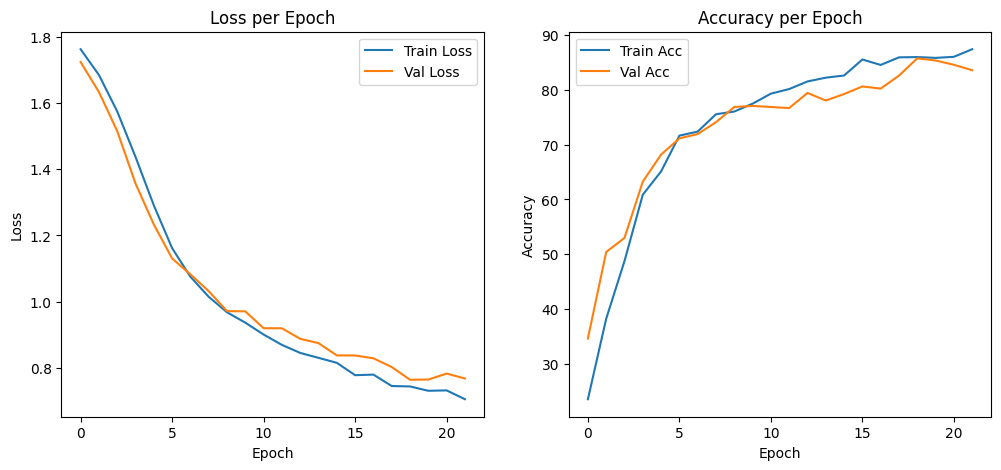

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Grafik Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Grafik Akurasi
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

<Figure size 1000x800 with 0 Axes>

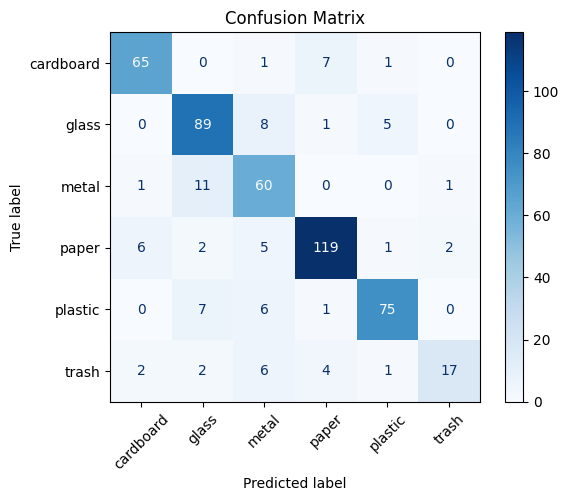

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Kumpulkan semua prediksi dan label asli
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 2. Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes)

plt.figure(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

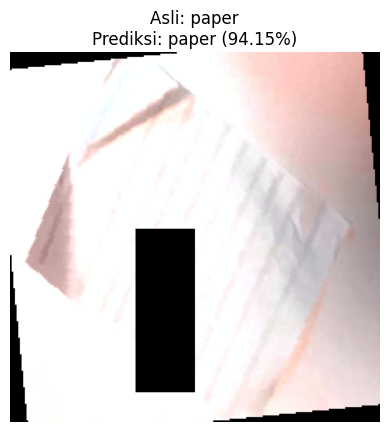

Model Benar


In [20]:
import random
import matplotlib.pyplot as plt

model.eval()

idx = random.randint(0, len(full_dataset) - 1)
img_tensor, label_idx = full_dataset[idx]

input_tensor = img_tensor.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.nn.functional.softmax(output, dim=1)
    conf, pred_idx = torch.max(probabilities, 1)

class_names = full_dataset.classes
true_label = class_names[label_idx]
pred_label = class_names[pred_idx.item()]

img_display = img_tensor.cpu().numpy().transpose((1, 2, 0))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_display = std * img_display + mean
img_display = np.clip(img_display, 0, 1)

plt.imshow(img_display)
plt.axis('off')
plt.title(f"Asli: {true_label}\nPrediksi: {pred_label} ({conf.item()*100:.2f}%)")
plt.show()

if true_label != pred_label:
    print("Model Salah")
else:
    print("Model Benar")